**Primitive lead Cavity**

Step 0, divergence = 0.000e+00


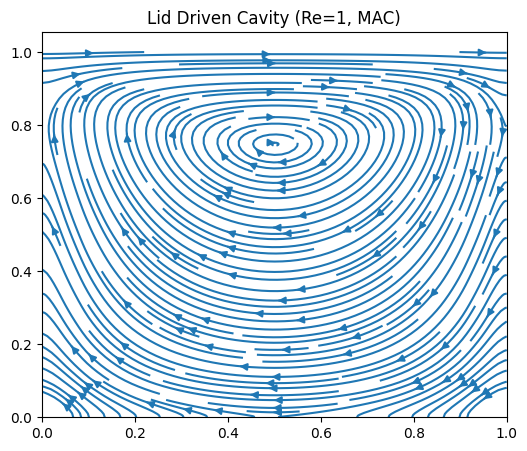

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Parameters
# -------------------------
Nx, Ny = 24, 24
Lx, Ly = 1.0, 1.0
dx, dy = Lx/Nx, Ly/Ny

Re = 1.0
nu = 1.0 / Re

dt = 0.0001     # diffusion-limited stable step
nt = 300
nit = 200       # Poisson iterations

# -------------------------
# Staggered grid variables
# -------------------------
u = np.zeros((Nx+1, Ny))      # u at vertical faces
v = np.zeros((Nx, Ny+1))      # v at horizontal faces
p = np.zeros((Nx, Ny))        # pressure at centers

u_star = np.zeros_like(u)
v_star = np.zeros_like(v)

# -------------------------
# Boundary Conditions
# -------------------------
def apply_bc(u, v):
    # u velocity
    u[0, :] = 0.0
    u[-1, :] = 0.0
    u[:, 0] = 0.0
    u[:, -1] = 1.0   # moving lid

    # v velocity
    v[0, :] = 0.0
    v[-1, :] = 0.0
    v[:, 0] = 0.0
    v[:, -1] = 0.0

# -------------------------
# Pressure Poisson
# -------------------------
def pressure_poisson(p, u_star, v_star):
    b = np.zeros_like(p)

    # RHS
    for i in range(1, Nx-1):
        for j in range(1, Ny-1):
            dudx = (u_star[i+1, j] - u_star[i, j]) / dx
            dvdy = (v_star[i, j+1] - v_star[i, j]) / dy
            b[i, j] = (dudx + dvdy) / dt

    # Iterations
    for _ in range(nit):
        pn = p.copy()

        for i in range(1, Nx-1):
            for j in range(1, Ny-1):
                p[i, j] = (
                    (pn[i+1, j] + pn[i-1, j]) * dy**2 +
                    (pn[i, j+1] + pn[i, j-1]) * dx**2 -
                    b[i, j] * dx**2 * dy**2
                ) / (2*(dx**2 + dy**2))

        # Neumann BC
        p[:, 0] = p[:, 1]
        p[:, -1] = p[:, -2]
        p[0, :] = p[1, :]
        p[-1, :] = p[-2, :]

    return p

# -------------------------
# Time loop
# -------------------------
for n in range(nt):

    un = u.copy()
    vn = v.copy()

    apply_bc(un, vn)

    # ---- Step 1: u* ----
    for i in range(1, Nx):
        for j in range(1, Ny-1):

            u_c = 0.5 * (un[i, j] + un[i-1, j])
            v_c = 0.25 * (vn[i-1, j] + vn[i-1, j+1] +
                          vn[i, j] + vn[i, j+1])

            du_dx = (un[i+1, j] - un[i-1, j]) / (2*dx)
            du_dy = (un[i, j+1] - un[i, j-1]) / (2*dy)

            conv = u_c * du_dx + v_c * du_dy

            lap = (
                (un[i+1, j] - 2*un[i, j] + un[i-1, j]) / dx**2 +
                (un[i, j+1] - 2*un[i, j] + un[i, j-1]) / dy**2
            )

            u_star[i, j] = un[i, j] + dt * (-conv + nu * lap)

    # ---- Step 1: v* ----
    for i in range(1, Nx-1):
        for j in range(1, Ny):

            u_c = 0.25 * (un[i, j-1] + un[i+1, j-1] +
                          un[i, j] + un[i+1, j])
            v_c = 0.5 * (vn[i, j] + vn[i, j-1])

            dv_dx = (vn[i+1, j] - vn[i-1, j]) / (2*dx)
            dv_dy = (vn[i, j+1] - vn[i, j-1]) / (2*dy)

            conv = u_c * dv_dx + v_c * dv_dy

            lap = (
                (vn[i+1, j] - 2*vn[i, j] + vn[i-1, j]) / dx**2 +
                (vn[i, j+1] - 2*vn[i, j] + vn[i, j-1]) / dy**2
            )

            v_star[i, j] = vn[i, j] + dt * (-conv + nu * lap)

    apply_bc(u_star, v_star)

    # ---- Step 2: Pressure ----
    p = pressure_poisson(p, u_star, v_star)

    # ---- Step 3: Projection ----
    for i in range(1, Nx):
        for j in range(1, Ny-1):
            u[i, j] = u_star[i, j] - dt * (p[i, j] - p[i-1, j]) / dx

    for i in range(1, Nx-1):
        for j in range(1, Ny):
            v[i, j] = v_star[i, j] - dt * (p[i, j] - p[i, j-1]) / dy

    apply_bc(u, v)

    # ---- Monitor ----
    if n % 500 == 0:
        div = 0.0
        for i in range(1, Nx-1):
            for j in range(1, Ny-1):
                dudx = (u[i+1, j] - u[i, j]) / dx
                dvdy = (v[i, j+1] - v[i, j]) / dy
                div += abs(dudx + dvdy)

        print(f"Step {n}, divergence = {div:.3e}")

# -------------------------
# Post-processing
# -------------------------
uc = 0.5 * (u[:-1, :] + u[1:, :])
vc = 0.5 * (v[:, :-1] + v[:, 1:])

X, Y = np.meshgrid(np.linspace(0,1,Nx),
                   np.linspace(0,1,Ny))

plt.figure(figsize=(6,5))
plt.streamplot(X, Y, uc.T, vc.T, density=2)
plt.title("Lid Driven Cavity (Re=1, MAC)")
plt.show()


**Steady SIMPLE Poisseulli Flow**

Iter 0, Residual = 9.975e-03
Iter 200, Residual = 4.772e-03
Iter 400, Residual = 2.484e-03


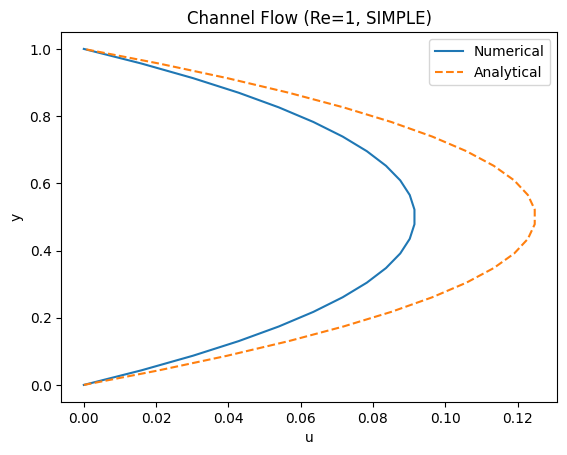

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Parameters
# -------------------------
Nx, Ny = 48, 24
Lx, Ly = 2.0, 1.0

dx, dy = Lx/Nx, Ly/Ny

Re = 1.0
nu = 1.0 / Re

G = 1.0   # driving force = -dp/dx

alpha_u = 0.7
alpha_p = 0.3

max_iter = 500
tol = 1e-6

# -------------------------
# Variables (staggered)
# -------------------------
u = np.zeros((Nx+1, Ny))
v = np.zeros((Nx, Ny+1))
p = np.zeros((Nx, Ny))

u_star = np.zeros_like(u)
v_star = np.zeros_like(v)
p_prime = np.zeros_like(p)

d_u = np.zeros_like(u)
d_v = np.zeros_like(v)

# -------------------------
# Boundary Conditions
# -------------------------
def apply_bc(u, v):
    # Wall (top/bottom)
    u[:, 0] = 0.0
    u[:, -1] = 0.0

    v[:, 0] = 0.0
    v[:, -1] = 0.0

    # Periodic in x
    u[0, :] = u[-2, :]
    u[-1, :] = u[1, :]

    v[0, :] = v[-1, :]
    v[-1, :] = v[0, :]

# -------------------------
# SIMPLE loop
# -------------------------
for it in range(max_iter):

    u_old = u.copy()
    v_old = v.copy()
    p_old = p.copy()

    apply_bc(u, v)

    # ---- u-momentum ----
    for i in range(1, Nx):
        for j in range(1, Ny-1):

            ae = nu * dy / dx
            aw = nu * dy / dx
            an = nu * dx / dy
            as_ = nu * dx / dy

            ap = ae + aw + an + as_

            dpdx = (p[i, j] - p[i-1, j]) / dx

            u_star[i, j] = (
                ae*u[(i+1)%Nx, j] + aw*u[(i-1)%Nx, j] +
                an*u[i, j+1] + as_*u[i, j-1]
                - dpdx * dx * dy
                + G * dx * dy
            ) / ap

            u_star[i, j] = alpha_u*u_star[i, j] + (1-alpha_u)*u[i, j]

            d_u[i, j] = dy / ap

    # ---- v-momentum ----
    for i in range(1, Nx-1):
        for j in range(1, Ny):

            ae = nu * dy / dx
            aw = nu * dy / dx
            an = nu * dx / dy
            as_ = nu * dx / dy

            ap = ae + aw + an + as_

            dpdy = (p[i, j] - p[i, j-1]) / dy

            v_star[i, j] = (
                ae*v[(i+1)%Nx, j] + aw*v[(i-1)%Nx, j] +
                an*v[i, j+1] + as_*v[i, j-1]
                - dpdy * dx * dy
            ) / ap

            v_star[i, j] = alpha_u*v_star[i, j] + (1-alpha_u)*v[i, j]

            d_v[i, j] = dx / ap

    apply_bc(u_star, v_star)

    # ---- pressure correction ----
    p_prime[:] = 0.0

    for _ in range(100):
        pp_old = p_prime.copy()

        for i in range(1, Nx-1):
            for j in range(1, Ny-1):

                ae = d_u[i+1, j] * dy
                aw = d_u[i, j] * dy
                an = d_v[i, j+1] * dx
                as_ = d_v[i, j] * dx

                ap = ae + aw + an + as_

                b = (
                    (u_star[i, j] - u_star[i+1, j]) * dy +
                    (v_star[i, j] - v_star[i, j+1]) * dx
                )

                p_prime[i, j] = (
                    ae*pp_old[i+1, j] + aw*pp_old[i-1, j] +
                    an*pp_old[i, j+1] + as_*pp_old[i, j-1] - b
                ) / ap

        # periodic pressure
        p_prime[0, :] = p_prime[-2, :]
        p_prime[-1, :] = p_prime[1, :]

        # wall Neumann
        p_prime[:, 0] = p_prime[:, 1]
        p_prime[:, -1] = p_prime[:, -2]

    # ---- correction ----
    for i in range(1, Nx):
        for j in range(1, Ny-1):
            u[i, j] = u_star[i, j] + d_u[i, j]*(p_prime[i-1, j] - p_prime[i, j])

    for i in range(1, Nx-1):
        for j in range(1, Ny):
            v[i, j] = v_star[i, j] + d_v[i, j]*(p_prime[i, j-1] - p_prime[i, j])

    p += alpha_p * p_prime

    apply_bc(u, v)

    # ---- convergence ----
    res = max(np.linalg.norm(u-u_old),
              np.linalg.norm(v-v_old),
              np.linalg.norm(p-p_old))

    if it % 200 == 0:
        print(f"Iter {it}, Residual = {res:.3e}")

    if res < tol:
        print(f"Converged at {it}")
        break

# -------------------------
# Post-processing
# -------------------------
uc = 0.5*(u[:-1,:] + u[1:,:])

y = np.linspace(0, Ly, Ny)

plt.plot(uc[Nx//2, :], y, label="Numerical")

# Analytical Poiseuille
u_exact = G/(2*nu) * y*(Ly - y)
plt.plot(u_exact, y, '--', label="Analytical")

plt.xlabel("u")
plt.ylabel("y")
plt.legend()
plt.title("Channel Flow (Re=1, SIMPLE)")
plt.show()
